**Libraries**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, models, transforms
from PIL import Image
import pandas as pd
import numpy as np
from collections import Counter
import os
from torchvision.models import ResNet50_Weights, efficientnet_b3, EfficientNet_B3_Weights
from tqdm import tqdm
from IPython.display import Image, display

**Data Preprossing**

In [ ]:
DATA_DIR = '/kaggle/input/AI-OF-GOD-4/aog_data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test', 'images')
SAMPLE_SUBMISSION_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
NUM_EPOCHS = 13
WARMUP_EPOCHS = 2
VALIDATION_SPLIT = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")3

**Transformation used on data**

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

**Handling Class Imbalance**

In [ ]:
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
class_counts = Counter(full_train_dataset.targets)
total_samples = len(full_train_dataset)
num_classes = len(class_counts)
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
class_weights_tensor = torch.tensor([class_weights[i] for i in range(num_classes)], dtype=torch.float).to(DEVICE)

print(f"Class counts: {class_counts}")
print(f"Calculated class weights: {class_weights_tensor}")

**class-imbalance image**

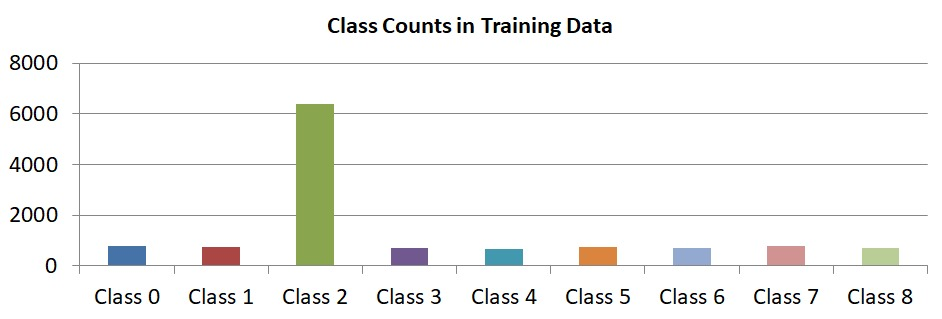

In [7]:
display(Image("/kaggle/input/class-imbalance/WhatsApp Image 2025-10-26 at 16.26.17_a0a75961.jpg"))

In [ ]:
num_train_samples = len(full_train_dataset)
num_val_samples = int(num_train_samples * VALIDATION_SPLIT)
num_train_samples -= num_val_samples
train_subset, val_subset = random_split(full_train_dataset, [num_train_samples, num_val_samples])

In [ ]:
class ValDatasetWrapper(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img_tensor, label = self.dataset[idx]
        unnormalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_tensor_unnormalized = unnormalize(img_tensor)
        original_pil_image = transforms.ToPILImage()(torch.clamp(img_tensor_unnormalized, 0, 1))
        return self.transform(original_pil_image), label

val_dataset = ValDatasetWrapper(val_subset, val_test_transforms)

In [ ]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

test_dataset = TestDataset(TEST_DIR, transform=val_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

**Model training**

In [ ]:
model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_ftrs, num_classes)
model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    if epoch < WARMUP_EPOCHS:
        lr_scale = (epoch + 1) / WARMUP_EPOCHS
        for g in optimizer.param_groups:
            g['lr'] = LEARNING_RATE * lr_scale
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader.dataset)
    
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.double() / len(val_loader.dataset)

    if epoch >= WARMUP_EPOCHS:
        scheduler.step()
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] -> Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")


**Submission and Evaluation**

In [ ]:
model.eval()
predictions, filenames = [], []
with torch.no_grad():
    for images, fnames in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())
        filenames.extend(fnames)

submission_df = pd.DataFrame({'filename': filenames, 'label': predictions})
submission_df.to_csv("submission.csv", index=False)